In [66]:
from dotenv import load_dotenv , find_dotenv
import os
dotenv_path = find_dotenv()

load_dotenv(find_dotenv())
api_key = os.getenv("OPENAI_API_KEY")
langsmith_key = os.getenv("LANGSMITH_API_KEY")

if api_key is None:
    raise ValueError("OPENAI_API_KEY not found in environment variables")


In [68]:
#loadig the model
from langchain.chat_models import init_chat_model
llm = init_chat_model("gpt-4o-mini", model_provider = "openai")

In [69]:
#selecting the embedding
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large") 

In [70]:
#choosing the VDB.
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS


embedding_dim = len(embeddings.embed_query("hello world"))
index = faiss.IndexFlatL2(embedding_dim)

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id= {},


)

In [71]:

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.document_loaders import PyPDFLoader



In [72]:
loader = PyPDFLoader("C:\\Users\\Admin\\Documents\\gen_ai_training\\pdfs\\rag.pdf")
docs = loader.load()
# print(docs)

In [73]:
#chunks splitting 
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
print(all_splits)

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-03-28T00:54:45+00:00', 'author': '', 'keywords': '', 'moddate': '2024-03-28T00:54:45+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'C:\\Users\\Admin\\Documents\\gen_ai_training\\pdfs\\rag.pdf', 'total_pages': 21, 'page': 0, 'page_label': '1'}, page_content='1\nRetrieval-Augmented Generation for Large\nLanguage Models: A Survey\nYunfan Gaoa, Yun Xiongb, Xinyu Gaob, Kangxiang Jiab, Jinliu Panb, Yuxi Bic, Yi Daia, Jiawei Suna, Meng\nWangc, and Haofen Wanga,c\naShanghai Research Institute for Intelligent Autonomous Systems, Tongji University\nbShanghai Key Laboratory of Data Science, School of Computer Science, Fudan University\ncCollege of Design and Innovation, Tongji University\nAbstract —Large Language Models (LLMs) showcase impres-\nsive capabilities bu

In [74]:
# Index chunks
_ = vector_store.add_documents(documents=all_splits)   


In [75]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)



In [76]:
#Tool-calling, this allows a model to rewrite user queries into more effective search queries.

from langchain_core.tools import tool   

@tool(response_format="content_and_artifact")
def retrieve(query:str):
    """Retrieve information related to a query."""
    retrieved_docs  = vector_store.similarity_search(query, k= 2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs




In [ ]:
#Our graph will consist of three nodes:

# A node that fields the user input, either generating a query for the retriever or responding directly;
# A node for the retriever tool that executes the retrieval step;
# A node that generates the final response using the retrieved context.

# we use ToolNode , that executes the tool and adds the result as a ToolMessage in the state

from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

#step 1 : function that fields the user input by responding directly or using the model to generate a query 
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond"""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    #MessagesState appends messages into state instead of overwriting
    return {"messages":[response]}

#step 2 : Execute the retrieval 
tools = ToolNode([retrieve])

#step 3 : function that generates response using retrieved content
def generate(state: MessagesState):
    """Generate answer."""
    #get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    #format into prompt 
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )

    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]

    prompt = [SystemMessage(content=system_message_content)]+ conversation_messages

    #run 
    response = llm.invoke(prompt)
    return {"messages": [response]}

In [62]:
#compiling our application into a single graph object


from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node("query_or_respond", query_or_respond)
graph_builder.add_node("tools", tools)
graph_builder.add_node("generate", generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END:END, "tools": "tools"},
)

graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

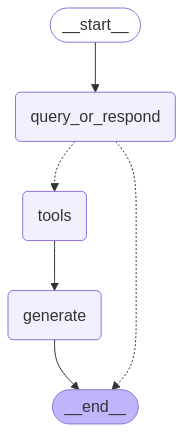

In [63]:
#visualization of our graph object
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
#Let's test our application.

#Note that it responds appropriately to messages that do not require an additional retrieval step:


input_message = "Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?


In [65]:
#when executing a search, we can stream the steps to 
# observe the query generation, retrieval, and answer generation:
input_message = "what is native rag ?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

what is native rag ?
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_UajDi7CkhOjRgORmDL89AtNO)
 Call ID: call_UajDi7CkhOjRgORmDL89AtNO
  Args:
    query: native rag
================================= Tool Message =================================
Name: retrieve

Source: {'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-03-28T00:54:45+00:00', 'author': '', 'keywords': '', 'moddate': '2024-03-28T00:54:45+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'C:\\Users\\Admin\\Documents\\gen_ai_training\\pdfs\\rag.pdf', 'total_pages': 21, 'page': 2, 'page_label': '3'}
Content: query may not suffice to acquire adequate context information.
Moreover, there’s a concern that generation models mig

NameError: name 'ToolMessage' is not defined